# 239 — 경로 순위 뒤집힘 실험: 세 해상도에서 후보 순위가 얼마나 바뀌나

**목적**: 혼잡도가 경로 추천에 "의미 있게" 영향을 주는가를, 세 해상도 — (a) 정적 lookup 표 ·
(b) 30분 모델 표 · (c) 노드×열차 표 — 에서 만든 같은 OD·같은 후보·같은 출발 시각의 순위 변화로
잰다. 수치 원본·실행 조건·재현 명령은 [`RESULTS.md`](./RESULTS.md)에 있고, 이 노트북과 어긋나면
그쪽이 맞다.

In [1]:
import json
import sys
from pathlib import Path

AI_ROOT = Path.cwd()
while not (AI_ROOT / "app" / "CROWD").exists():
    AI_ROOT = AI_ROOT.parent
sys.path.insert(0, str(AI_ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from DATA_ENGINE.eda import figstyle

figstyle.apply(inline=True)

RUN_DIRS = {
    "1 d7_only": AI_ROOT / "data" / "CROWD" / "interim" / "validation" / "route_ranking",
    "2 full": AI_ROOT / "data" / "CROWD" / "interim" / "validation" / "route_ranking" / "run2025",
}
RUNS = list(RUN_DIRS)
TIMES = ["08:00", "14:00", "23:00"]
PAIR_ORDER = ["lookup_vs_model", "model_vs_train", "lookup_vs_train"]
PAIR_LABELS = {
    "lookup_vs_model": "(a) lookup\n→ (b) model",
    "model_vs_train": "(b) model\n→ (c) train",
    "lookup_vs_train": "(a) lookup\n→ (c) train",
}

frames = []
summaries = {}
for run, d in RUN_DIRS.items():
    frame = pd.read_csv(d / "candidates.csv")
    frame["run"] = run
    frames.append(frame)
    summaries[run] = json.loads((d / "summary.json").read_text(encoding="utf-8"))
cand = pd.concat(frames, ignore_index=True)

print("행 수(candidates.csv):")
print(cand.groupby("run").size().to_string())

n_cand_by_case = (
    cand[cand["resolution"] == "lookup"]
    .groupby(["run", "date", "time", "od_id"])
    .size()
    .rename("n_cand")
    .reset_index()
)
print("\n케이스당 후보 수 분포:")
print(n_cand_by_case.groupby(["run", "n_cand"]).size().unstack(fill_value=0).to_string())

행 수(candidates.csv):
run
1 d7_only    13302
2 full       19953

케이스당 후보 수 분포:
n_cand       1    2     3
run                      
1 d7_only  300  366  1134
2 full     450  549  1701


## 1. 표 R — 상위 1위 경로가 바뀐 비율

`summary.json`의 `pairs`(해상도 쌍별 1위 변경률·95% CI)를 실행 1·2 나란히 놓는다.

           pair       run   rate  ci_lo  ci_hi  gap_mean  gap_median
lookup_vs_model 1 d7_only 0.0300 0.0222 0.0389    2.2727      1.7728
 model_vs_train 1 d7_only 0.1683 0.1472 0.1900    2.3746      1.2547
lookup_vs_train 1 d7_only 0.1739 0.1528 0.1956    3.0888      1.9407
lookup_vs_model    2 full 0.0544 0.0452 0.0637    4.1844      3.4343
 model_vs_train    2 full 0.1867 0.1656 0.2085    3.1496      1.4973
lookup_vs_train    2 full 0.1907 0.1700 0.2133    4.0918      2.7460


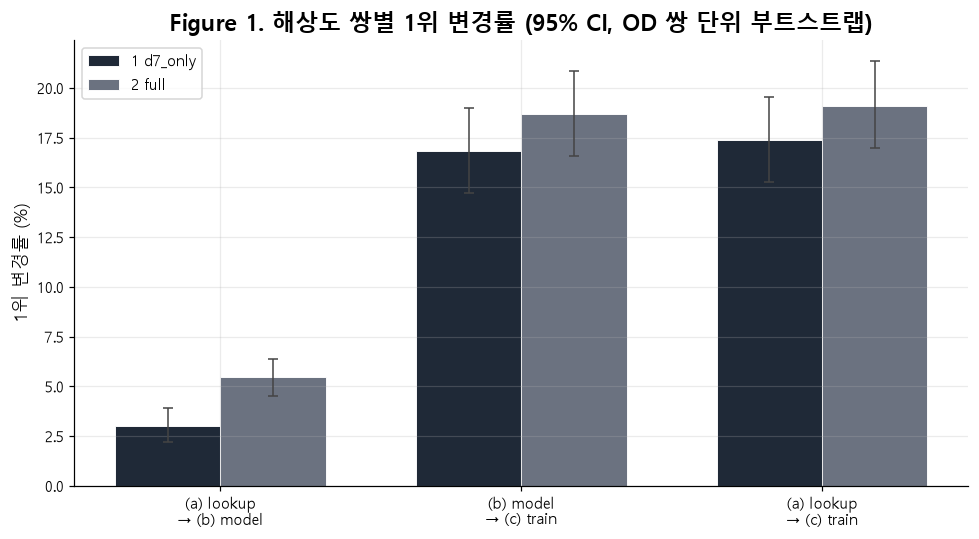

In [2]:
rows = []
for run, summary in summaries.items():
    for p in summary["pairs"]:
        lo, hi = p["top1_changed_rate_ci95"]
        rows.append(
            {
                "run": run,
                "pair": p["pair"],
                "rate": p["top1_changed_rate"],
                "ci_lo": lo,
                "ci_hi": hi,
                "gap_mean": p["gap_mean_when_changed"],
                "gap_median": p["gap_median_when_changed"],
            }
        )
table_r = pd.DataFrame(rows)
print(table_r[["pair", "run", "rate", "ci_lo", "ci_hi", "gap_mean", "gap_median"]]
      .round(4).to_string(index=False))

x = np.arange(len(PAIR_ORDER))
width = 0.35
fig, ax = plt.subplots(figsize=(9, 5))
for i, run in enumerate(RUNS):
    sub = table_r[table_r["run"] == run].set_index("pair").reindex(PAIR_ORDER)
    point = sub["rate"].to_numpy() * 100
    err = [
        (sub["rate"].to_numpy() - sub["ci_lo"].to_numpy()) * 100,
        (sub["ci_hi"].to_numpy() - sub["rate"].to_numpy()) * 100,
    ]
    ax.bar(x + (i - 0.5) * width, point, width, yerr=err, capsize=3, label=run,
           color=figstyle.PALETTE_NEUTRAL[i], edgecolor="white", linewidth=0.6,
           error_kw={"ecolor": "#444", "elinewidth": 1.0})
ax.set_xticks(x)
ax.set_xticklabels([PAIR_LABELS[p] for p in PAIR_ORDER])
ax.set_ylabel("1위 변경률 (%)")
ax.set_title("Figure 1. 해상도 쌍별 1위 변경률 (95% CI, OD 쌍 단위 부트스트랩)")
ax.legend()
fig.tight_layout()
_ = figstyle.save(fig, "route_ranking_fig1_top1_changed_rate")

## 2. 시간대별 1위 변경률

08:00·14:00·23:00 각각에서 (a)→(b), (b)→(c) 변경률이 실행 1·2에서 어떻게 갈리는지 본다.

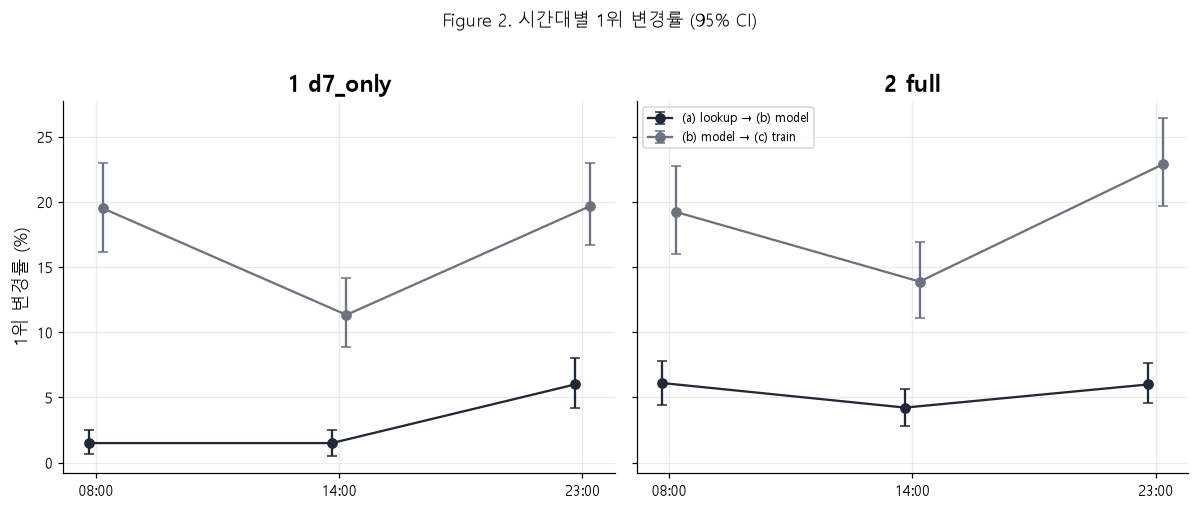

In [3]:
time_rows = []
for run, summary in summaries.items():
    for t in TIMES:
        for p in summary["by_time"][t]:
            lo, hi = p["top1_changed_rate_ci95"]
            time_rows.append(
                {"run": run, "time": t, "pair": p["pair"], "rate": p["top1_changed_rate"],
                 "ci_lo": lo, "ci_hi": hi}
            )
time_df = pd.DataFrame(time_rows)

LINE_PAIRS = ["lookup_vs_model", "model_vs_train"]
xt = np.arange(len(TIMES))
fig, axes = plt.subplots(1, len(RUNS), figsize=(11, 4.5), sharey=True)
for ax, run in zip(axes, RUNS):
    sub_run = time_df[time_df["run"] == run]
    for i, pair in enumerate(LINE_PAIRS):
        sub = sub_run[sub_run["pair"] == pair].set_index("time").reindex(TIMES)
        point = sub["rate"].to_numpy() * 100
        err = [
            (sub["rate"].to_numpy() - sub["ci_lo"].to_numpy()) * 100,
            (sub["ci_hi"].to_numpy() - sub["rate"].to_numpy()) * 100,
        ]
        ax.errorbar(xt + (i - 0.5) * 0.06, point, yerr=err, fmt="o-", capsize=3,
                    label=PAIR_LABELS[pair].replace("\n", " "), color=figstyle.PALETTE_NEUTRAL[i])
    ax.set_xticks(xt)
    ax.set_xticklabels(TIMES)
    ax.set_title(run)
axes[0].set_ylabel("1위 변경률 (%)")
axes[-1].legend(fontsize=8, loc="upper left")
fig.suptitle("Figure 2. 시간대별 1위 변경률 (95% CI)", y=1.02)
fig.tight_layout()
_ = figstyle.save(fig, "route_ranking_fig2_by_time")

## 3. 같은 후보의 값이 얼마나 움직였나

경로(= `cand_id`)는 그대로 두고 표시 값(`mean_tw`)만 해상도 사이에서 비교한다 —
`(run, date, time, od_id, cand_id)`로 피벗해 `|model − lookup|`, `|train − model|`을 잰다.

1 d7_only |model - lookup|: 중앙값=0.85 p90=3.43 p99=6.60 (n=4434)
1 d7_only |train - model|: 중앙값=1.22 p90=5.01 p99=14.34 (n=4434)
2 full |model - lookup|: 중앙값=2.23 p90=7.23 p99=16.32 (n=6651)
2 full |train - model|: 중앙값=1.47 p90=6.32 p99=19.61 (n=6651)

실행 2 날짜별 |model-lookup| 중앙값 (기대: 경기일 3.45 · 평일 0.94 · 공휴일 5.38):
date
2025-05-03    3.45
2025-06-04    0.94
2025-10-03    5.38


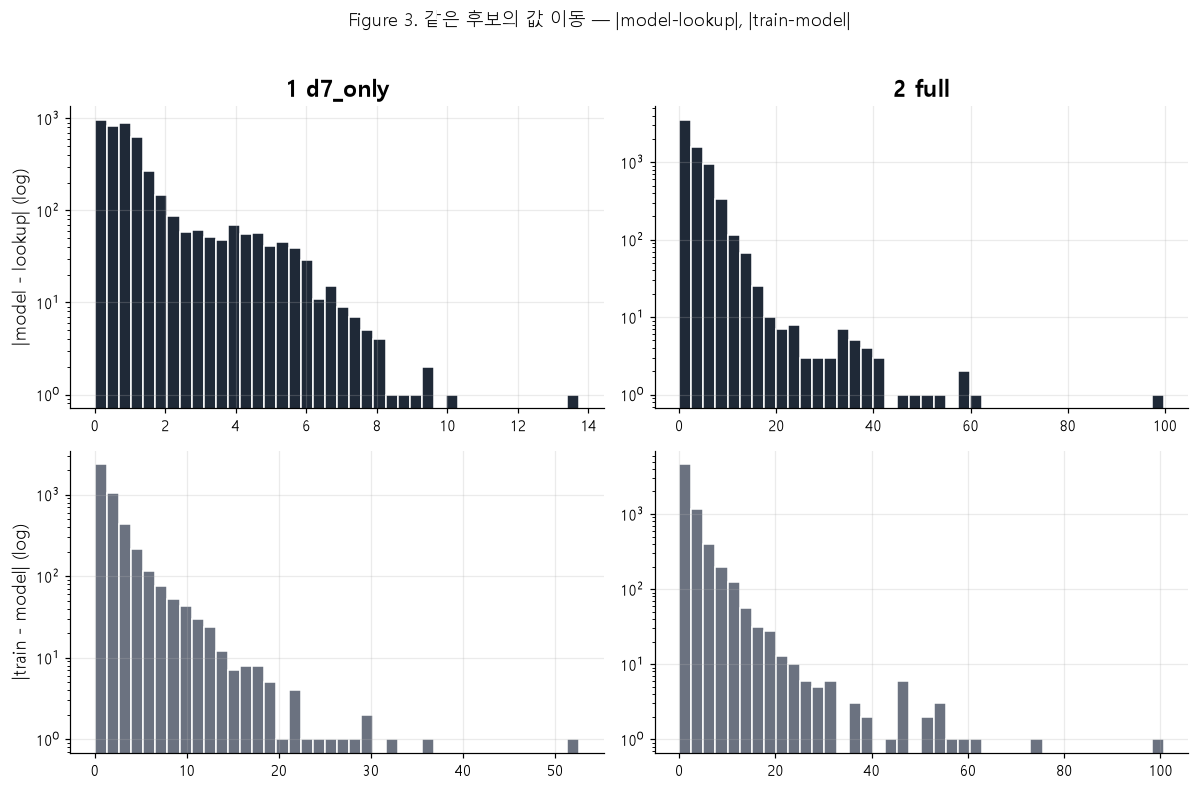

In [4]:
piv = cand.pivot_table(
    index=["run", "date", "time", "od_id", "cand_id"], columns="resolution", values="mean_tw"
)
piv["diff_model_lookup"] = (piv["model"] - piv["lookup"]).abs()
piv["diff_train_model"] = (piv["train"] - piv["model"]).abs()

DIFF_COLS = ["diff_model_lookup", "diff_train_model"]
DIFF_TITLES = ["|model - lookup|", "|train - model|"]
fig, axes = plt.subplots(2, len(RUNS), figsize=(11, 7))
for row, (col, title) in enumerate(zip(DIFF_COLS, DIFF_TITLES)):
    for c, run in enumerate(RUNS):
        ax = axes[row][c]
        vals = piv.xs(run, level="run")[col].dropna()
        ax.hist(vals, bins=40, color=figstyle.PALETTE_NEUTRAL[row], edgecolor="white")
        ax.set_yscale("log")
        if row == 0:
            ax.set_title(run)
        if c == 0:
            ax.set_ylabel(f"{title} (log)")
fig.suptitle("Figure 3. 같은 후보의 값 이동 — |model-lookup|, |train-model|", y=1.02)
fig.tight_layout()
_ = figstyle.save(fig, "route_ranking_fig3_value_shift")

for run in RUNS:
    for col, title in zip(DIFF_COLS, DIFF_TITLES):
        vals = piv.xs(run, level="run")[col].dropna()
        print(f"{run} {title}: 중앙값={vals.median():.2f} p90={vals.quantile(0.9):.2f} "
              f"p99={vals.quantile(0.99):.2f} (n={len(vals)})")

by_date_run2 = (
    piv.xs("2 full", level="run")["diff_model_lookup"].dropna().reset_index()
    .groupby("date")["diff_model_lookup"].median()
)
print("\n실행 2 날짜별 |model-lookup| 중앙값 (기대: 경기일 3.45 · 평일 0.94 · 공휴일 5.38):")
print(by_date_run2.round(2).to_string())

## 4. 근접 케이스 — (b)→(c) 변경이 어디서 나는가

후보 ≥ 2인 케이스만 대상으로, (b) 기준 1·2위 격차(margin)와 (b)→(c) 1위 변경 여부를 같이 본다.

1 d7_only: 후보>=2 케이스 1500 · (b)->(c) 변경률=0.202 · 변경 케이스 중 margin<2%p 비율=0.769
  전체 케이스 margin 25/50/75%: [0.93, 2.29, 4.96]
2 full: 후보>=2 케이스 2250 · (b)->(c) 변경률=0.224 · 변경 케이스 중 margin<2%p 비율=0.675
  전체 케이스 margin 25/50/75%: [1.05, 2.65, 5.95]


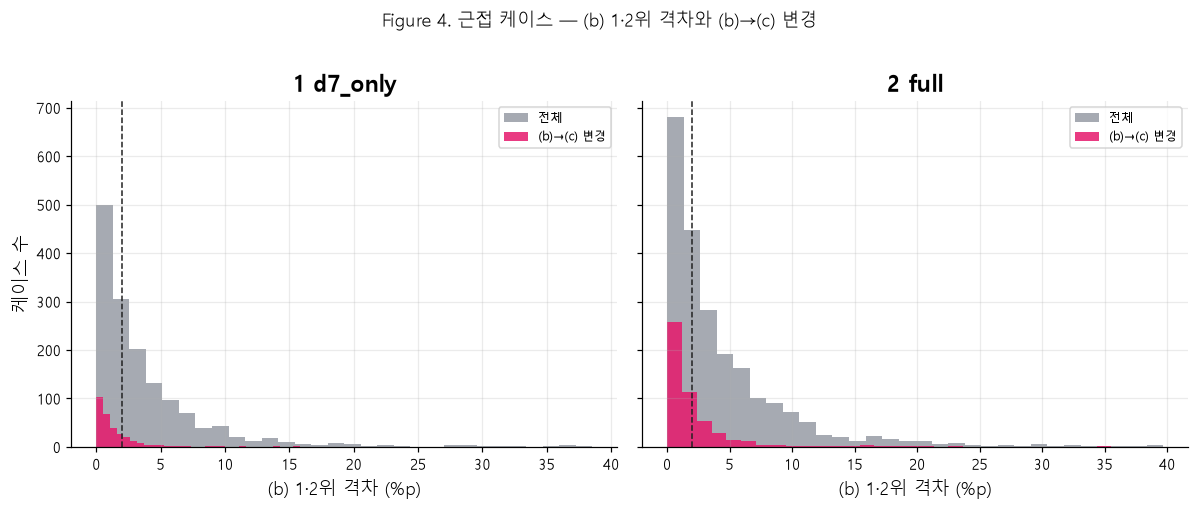

In [5]:
model_df = cand[cand["resolution"] == "model"]
n_cand_case = model_df.groupby(["run", "date", "time", "od_id"]).size().rename("n_cand")


def _top1_map(df, resolution):
    sub = df[(df["resolution"] == resolution) & (df["rank"] == 1)]
    sub = sub.drop_duplicates(["run", "date", "time", "od_id"])
    return sub.set_index(["run", "date", "time", "od_id"])["cand_id"]


t_model = _top1_map(cand, "model")
t_train = _top1_map(cand, "train")
top1_joined = pd.concat([t_model.rename("model"), t_train.rename("train")], axis=1).dropna()
top1_joined = top1_joined.join(n_cand_case)
ge2 = top1_joined[top1_joined["n_cand"] >= 2].copy()
ge2["changed"] = ge2["model"] != ge2["train"]

comparable_model = cand[(cand["resolution"] == "model") & (cand["comparable"])]


def _margin_of(group):
    vals = group.sort_values("mean_tw")["mean_tw"].to_numpy()
    return vals[1] - vals[0] if len(vals) >= 2 else np.nan


margins = (
    comparable_model.groupby(["run", "date", "time", "od_id"])
    .apply(_margin_of, include_groups=False)
    .rename("margin")
    .dropna()
)
merged = ge2.join(margins, how="left")

fig, axes = plt.subplots(1, len(RUNS), figsize=(11, 4.5), sharey=True)
for ax, run in zip(axes, RUNS):
    sub = merged.xs(run, level="run")
    all_margin = sub["margin"].dropna()
    flip_margin = sub.loc[sub["changed"], "margin"].dropna()
    ax.hist(all_margin, bins=30, color=figstyle.PALETTE_NEUTRAL[1], label="전체", alpha=0.6)
    ax.hist(flip_margin, bins=30, color=figstyle.COLOR_ACCENT, label="(b)→(c) 변경", alpha=0.85)
    ax.axvline(2.0, color="#222", linestyle="--", linewidth=1.0)
    ax.set_title(run)
    ax.set_xlabel("(b) 1·2위 격차 (%p)")
    ax.legend(fontsize=8)
axes[0].set_ylabel("케이스 수")
fig.suptitle("Figure 4. 근접 케이스 — (b) 1·2위 격차와 (b)→(c) 변경", y=1.02)
fig.tight_layout()
_ = figstyle.save(fig, "route_ranking_fig4_margin")

for run in RUNS:
    sub = merged.xs(run, level="run")
    rate = sub["changed"].mean()
    flip_margin = sub.loc[sub["changed"], "margin"].dropna()
    share_lt2 = (flip_margin < 2).mean()
    pct = sub["margin"].dropna().quantile([0.25, 0.5, 0.75])
    print(f"{run}: 후보>=2 케이스 {len(sub)} · (b)->(c) 변경률={rate:.3f} · "
          f"변경 케이스 중 margin<2%p 비율={share_lt2:.3f}")
    print(f"  전체 케이스 margin 25/50/75%: {pct.round(2).to_list()}")

## 5. 편안함 1위 vs 최단시간 1위

(b) 기준으로, 가장 빠른 후보와 가장 덜 붐비는(비교 가능한) 후보가 다른 케이스에서
혼잡도 이득(%p)과 대가(추가 소요 시간, 분)를 본다.

1 d7_only: 편안 1위 != 최단 1위 884/1794건
  이득(%p) 25/50/75/90% = [1.38, 3.25, 6.71, 11.71]
  이득>=10%p 비율=0.137 · 이득>=20%p 비율=0.027 · 추가시간 중앙값=8.0분
2 full: 편안 1위 != 최단 1위 1304/2691건
  이득(%p) 25/50/75/90% = [1.55, 3.93, 8.46, 14.66]
  이득>=10%p 비율=0.194 · 이득>=20%p 비율=0.043 · 추가시간 중앙값=8.0분


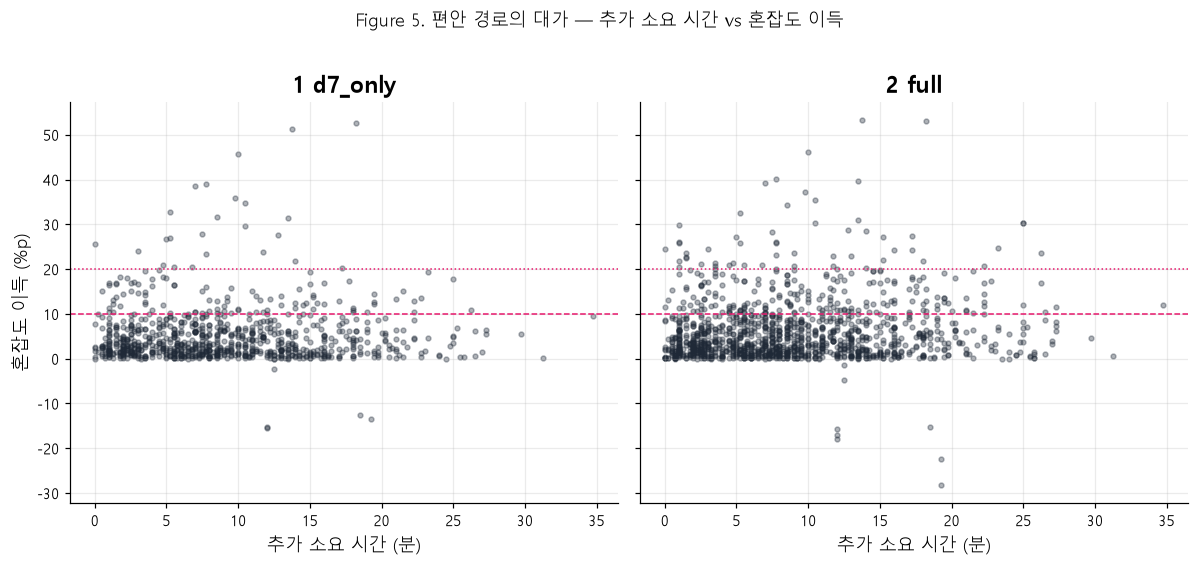

In [6]:
model_df = cand[cand["resolution"] == "model"]
fastest = model_df.loc[model_df.groupby(["run", "date", "time", "od_id"])["total_min"].idxmin()]
fastest = fastest.set_index(["run", "date", "time", "od_id"])[["cand_id", "total_min", "mean_tw"]]

top1_comfort = model_df[(model_df["rank"] == 1) & (model_df["comparable"])]
top1_comfort = top1_comfort.drop_duplicates(["run", "date", "time", "od_id"])
top1_comfort = top1_comfort.set_index(["run", "date", "time", "od_id"])[
    ["cand_id", "total_min", "mean_tw"]
]

joined = fastest.join(top1_comfort, lsuffix="_fast", rsuffix="_top1", how="inner")
differ = joined[joined["cand_id_fast"] != joined["cand_id_top1"]].copy()
differ["gain"] = differ["mean_tw_fast"] - differ["mean_tw_top1"]
differ["extra_min"] = differ["total_min_top1"] - differ["total_min_fast"]

fig, axes = plt.subplots(1, len(RUNS), figsize=(11, 5), sharex=True, sharey=True)
for ax, run in zip(axes, RUNS):
    sub = differ.xs(run, level="run")
    ax.scatter(sub["extra_min"], sub["gain"], s=10, alpha=0.35, color=figstyle.PALETTE_NEUTRAL[0])
    ax.axhline(10, color=figstyle.COLOR_ACCENT, linestyle="--", linewidth=1.0)
    ax.axhline(20, color=figstyle.COLOR_ACCENT, linestyle=":", linewidth=1.0)
    ax.set_title(run)
    ax.set_xlabel("추가 소요 시간 (분)")
axes[0].set_ylabel("혼잡도 이득 (%p)")
fig.suptitle("Figure 5. 편안 경로의 대가 — 추가 소요 시간 vs 혼잡도 이득", y=1.02)
fig.tight_layout()
_ = figstyle.save(fig, "route_ranking_fig5_comfort_tradeoff")

for run in RUNS:
    n_total = len(joined.xs(run, level="run"))
    sub = differ.xs(run, level="run")
    q = sub["gain"].quantile([0.25, 0.5, 0.75, 0.9])
    print(f"{run}: 편안 1위 != 최단 1위 {len(sub)}/{n_total}건")
    print(f"  이득(%p) 25/50/75/90% = {q.round(2).to_list()}")
    print(f"  이득>=10%p 비율={(sub['gain'] >= 10).mean():.3f} · "
          f"이득>=20%p 비율={(sub['gain'] >= 20).mean():.3f} · "
          f"추가시간 중앙값={sub['extra_min'].median():.1f}분")

## 6. 판정 (`RESULTS.md` 3절 원문)

1. **(a) → (b): 경로를 바꾸는 일은 드물고, 값을 바꾼다.** 1위 변경 3.0%(`d7_only`) / 5.4%(`full`), 경기일 7.6%·
   공휴일 6.8%. 대안 경로 간 혼잡도 차이(수십 %p)가 모델과 정적 표의 차이(같은 후보 중앙값 0.9~5.4%p)보다
   크기 때문이다. 대신 경기일·공휴일에는 같은 경로의 표시 값이 중앙값 3.5~5.4%p, 90퍼센타일 7%p 넘게
   움직이고 등급이 바뀌는 후보가 3.5%다 — **모델의 값어치는 "그 날의 수준"이고, 안내 문구도 그렇게 써야 한다**
   ("오늘 이 경로는 평소보다 N%p 붐빕니다"). 전날 실측이 없는 `d7_only`에서는 이 효과가 절반 이하로 준다
   (0.85%p) — 수집기 안정성이 곧 이 기능의 품질이다.
2. **(b) → (c): 순위는 자주 바뀌지만 근접 케이스다.** 17~19% 변경 중 68~77%가 (b)의 1·2위 격차가 2%p 미만인
   케이스다. 같은 후보의 값 이동 중앙값도 1.2~1.5%p라, 열차 단위가 **새 정보를 더하는 것이 아니라 근접 후보의
   동점을 열차 시각·배차 간격으로 정리하는 것**임이 수치로 확인된다(`RESOLUTION_LADDER.md` §3 L4 "정보가 있는
   열차 6~7%"와 같은 그림). 채택 근거는 노드 단위 시각 일관성(30분 경계 문제 해소)이지 정확도가 아니다.
3. **혼잡도 고려의 의미는 대안 제시에 있다.** 케이스의 48~49%에서 가장 덜 붐비는 후보가 가장 빠른 후보와
   다르고, 그중 14~20%(전체 7~9%)는 10%p 이상 덜 붐빈다 — 중앙값 +8분 대가로 4%p. 이 수치가 "혼잡 회피 경로"
   기능이 사용자에게 줄 수 있는 것의 크기다. 세 해상도 모두 이 비율이 같으므로(48~49%) **이 기능의 근거는
   해상도가 아니라 링크 간 혼잡도 격차 자체**다.

## 7. 한계

- **BE 그래프가 아니다.** `topology.resolve_segments` + 시각표로 만든 근사 그래프라, 실제 경로
  안내(환승 가중치·도보·버스·자전거)와 후보 집합이 다르다 — 위 비율은 지하철 단독 경로 안의 값이다.
- **열차 표 coverage가 0.92 안팎이다.** 23:00 출발은 막차 이후 탑승 열차를 못 찾는 경우가 있어
  `comparable=False`로 빠지고, 그만큼 (b)→(c) 비교 표본이 준다.
- **후보가 1개뿐인 케이스(약 17%)는 순위가 바뀔 수 없어** 전체 변경률을 낮추는 쪽으로 작용한다 —
  4절 "근접 케이스"는 후보 ≥ 2 케이스로만 다시 잰 값이다.

재현 명령은 `RESULTS.md` 5절을 그대로 따른다(패널·시각표·배치 표를 먼저 만들고
`run_ranking.py`로 `candidates.csv`/`summary.json`을 생성한 뒤, 이 노트북은 그 결과만 그림으로
다시 읽는다).